In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)

In [2]:
df = pd.read_csv('heart.csv')
print(df.shape)       # (1025, 14)
print(df.head())
print(df.info())

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null 

target
1    526
0    499
Name: count, dtype: int64


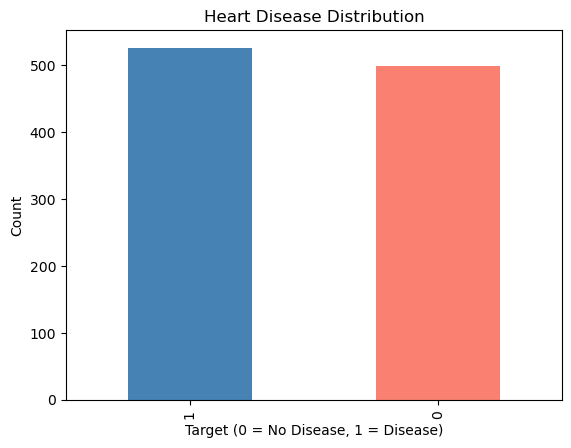

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


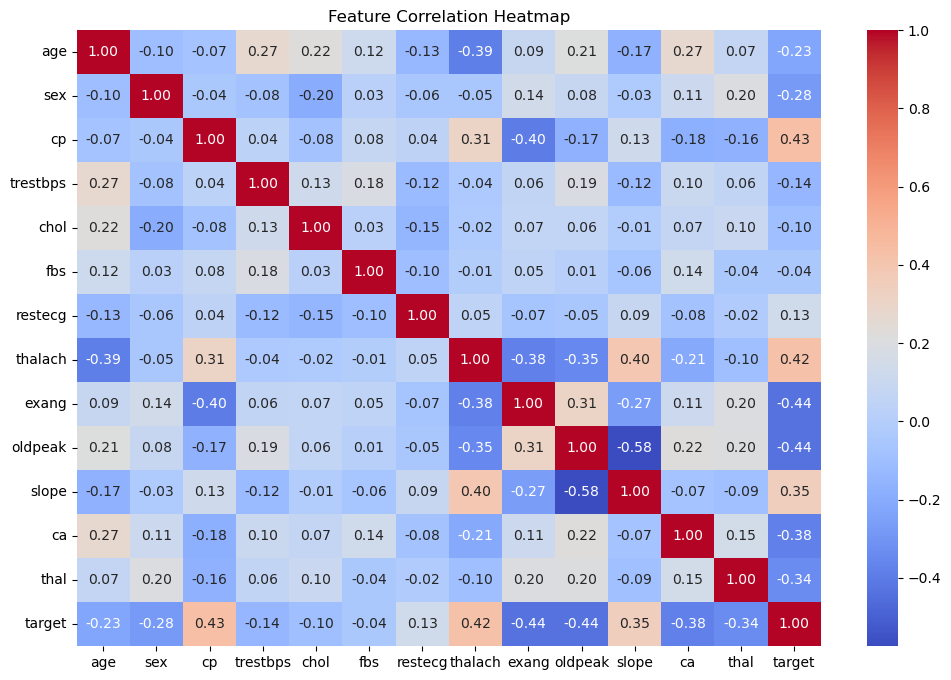

In [3]:
# Check class distribution
print(df['target'].value_counts())
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

# Check for missing values
print(df.isnull().sum())  # All zeros - no missing values!

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale features (good practice even for Random Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (820, 13)
Testing size: (205, 13)


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=None,      # let trees grow fully
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

   No Disease       1.00      1.00      1.00       100
Heart Disease       1.00      1.00      1.00       105

     accuracy                           1.00       205
    macro avg       1.00      1.00      1.00       205
 weighted avg       1.00      1.00      1.00       205



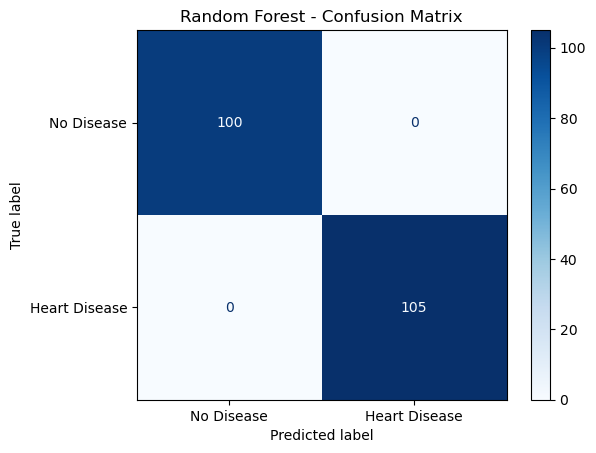

In [6]:
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Heart Disease']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()